# 09 · Machine Learning for Forecasting

Every model so far was built *for* time series: it knows that observations are ordered and that today follows yesterday. Machine-learning methods such as linear regression and gradient boosting know nothing of the sort. They learn a mapping from a row of **features** to a **target**. We can still use them for forecasting, by turning the series into a table where every row is a forecast origin, the features are what's known at that origin, and the target is the value some days later.

This recipe is one of the most effective approaches in practice. Gradient-boosted trees on lag features won several major forecasting competitions. It also opens the door to **leakage** more widely than any method so far, because a generic learner will happily use any column you hand it, including ones that secretly contain the future.

**By the end of this chapter you will be able to**

- reframe forecasting as **supervised learning**, with a clear rule for what may be a feature
- build **lag, rolling-window, calendar and weather** features that are known at the forecast origin
- train **one model per horizon** (the *direct* strategy) with an honest training cut-off
- compare a **linear model** with **gradient boosting**, and explain why more flexible isn't automatically better
- recognise three leakage traps, and measure how much each would flatter your results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

import tsutils

threadpool_limits(1)        # on small tables, multi-threaded tree fitting is slower, not faster
tsutils.set_style()
pd.set_option("display.precision", 3)

daily = tsutils.load_daily_pm25()
y, actual = daily["pm25"], daily["actual"]
weather = tsutils.load_daily_weather()
origins, H = tsutils.BACKTEST_ORIGINS, tsutils.HORIZON

---
## 1. Forecasting as a table

Take one forecast origin, the end of day $T$. We want $y_{T+h}$. A supervised learner needs a row of features $x_T$ and a target $y_{T+h}$, and it learns $f$ in $y_{T+h} \approx f(x_T)$ from many past rows.

The one rule that matters:

> **Every feature in row $T$ must be known by the end of day $T$.**

Values of the series up to $T$, today's weather and the calendar are allowed. The calendar is allowed even for the *target* date, because we know in advance that $T + 3$ is a Saturday or Spring Festival. Anything computed from days after $T$ is forbidden: centred windows, interpolation across the future, future weather.

There are two ways to forecast several days ahead:

| Strategy | How it works | Trade-off |
|---|---|---|
| **Recursive** | train one model for $h = 1$, then feed each forecast back in as if it were data | one model; errors compound, and future weather features have to be invented |
| **Direct** | train a separate model for each $h$ | $H$ models, each fitted exactly to its own horizon |

Chapter 05 showed why fitting to the right horizon matters: SES tuned per horizon beat one-size-fits-all. We use the **direct** strategy here, and Exercise 1 compares the two.

---
## 2. Features

`tsutils.ml_features(y, weather, horizon)` builds one row per day. Here's what's in it, and why each block is allowed:

| Block | Columns | Known at the origin because… |
|---|---|---|
| **Lags** of log PM2.5 | `lag_0` (today), `lag_1`, `lag_2`, `lag_3`, `lag_6`, `lag_13`, `lag_27` | they're past values |
| **Trailing statistics** | 3-, 7- and 30-day means, 7-day standard deviation, today's change | windows end today (chapter 01's *trailing, not centred*) |
| **Today's weather** | wind direction shares, humidity, evening wind and humidity, pressure and humidity changes | observed by the end of the day (chapter 07, approach C) |
| **Target calendar** | Fourier terms of the target's day of year, its weekday, Spring Festival flags | the calendar is known in advance |

We work with **log** PM2.5 as the target (chapter 04: exponentiating a log forecast gives a median-type forecast, which suits MAE).

In [2]:
X1 = tsutils.ml_features(y, weather, horizon=1)
print(X1.shape)
X1.loc["2014-01-29":"2014-02-01"].T

(2191, 27)


timestamp,2014-01-29,2014-01-30,2014-01-31,2014-02-01
lag_0,5.006,4.267,5.113,5.044
lag_1,3.841,5.006,4.267,5.113
lag_2,4.566,3.841,5.006,4.267
lag_3,4.078,4.566,3.841,5.006
lag_6,5.664,5.026,3.518,4.078
lag_13,6.106,5.040,4.341,4.826
lag_27,5.122,3.997,5.043,4.619
mean_3,4.471,4.372,4.796,4.808
mean_7,4.528,4.329,4.341,4.559
mean_30,4.469,4.481,4.516,4.513


The last rows show the Spring Festival flags switching on as the target date reaches Lunar New Year's Eve and Day 2014. The first 27 rows of the table have missing lags, and we'll simply drop incomplete rows.

---
## 3. Training honestly: the target date is what counts

Each model is **refitted at the first origin of every month** and used for the rest of that month, the schedule from chapter 07. The subtle part is which rows may be used for training at a refit date $R$.

A row dated $t$ holds features from day $t$ and a target from day $t + h$. It's usable only if **$t + h \le R$**, meaning its *target* has also been observed by $R$. Requiring only $t \le R$ would train on targets from up to $h$ days after the refit date: the very days we're about to forecast. That's trap number three in section 6.

In [3]:
def direct_forecasts(make_model, horizons=range(1, H + 1), origins_=origins, drop=(),
                     features=None, cutoff="target"):
    """One model per horizon, refitted at the first origin of each month.

    cutoff="target": train on rows whose target date is on or before the refit date (honest).
    cutoff="row":    train on rows whose own date is on or before it (leaky; section 6).
    Returns {(origin, h): forecast on the original scale}.
    """
    forecasts = {}
    log_actual = np.log(actual)
    for h in horizons:
        X = (tsutils.ml_features(y, weather, h) if features is None else features(h)).drop(columns=list(drop))
        target = log_actual.shift(-h)                     # log PM2.5 h days after each row's date
        complete = X.notna().all(axis=1) & target.notna()
        month_groups = pd.Series(origins_, index=origins_).groupby([origins_.year, origins_.month])
        for _, month_origins in month_groups:
            refit = month_origins.iloc[0]
            last_row = refit - pd.Timedelta(days=h) if cutoff == "target" else refit
            usable = complete & (X.index <= last_row)
            model = make_model().fit(X[usable], target[usable])
            predictions = np.exp(model.predict(X.loc[month_origins.to_numpy()]))
            forecasts.update({(o, h): p for o, p in zip(month_origins, predictions)})
    return forecasts

def score(forecasts, origins_=origins, horizon=H):
    lookup = lambda history, steps: np.array([forecasts[(history.index[-1], k)] for k in range(1, steps + 1)])
    return tsutils.evaluate(tsutils.backtest(y, lookup, origins_, horizon, actuals=actual))

---
## 4. Two learners

- **Ridge regression**: a linear model with a small penalty on coefficient size, fitted on standardised features. It can only add up weighted features.
- **Gradient boosting** (`HistGradientBoostingRegressor`): hundreds of small decision trees, each correcting the previous ones' errors. It can model interactions and non-linear effects, such as "north-westerly wind matters only when humidity is high".

In [4]:
def ridge():
    return make_pipeline(StandardScaler(), Ridge(alpha=1.0))

def boosting():
    return HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, max_leaf_nodes=15,
                                         min_samples_leaf=20, random_state=0)

ml_scores = {
    "Ridge, direct": score(direct_forecasts(ridge)),
    "Gradient boosting, direct": score(direct_forecasts(boosting)),
}
for name, s in ml_scores.items():
    tsutils.save_scores(name, s)

board = tsutils.load_scores().pivot(index="h", columns="model", values="MAE")
leaders = ["climatology (median)", "AR(2) on anomalies", "SARIMAX, today's weather",
           "Ridge, direct", "Gradient boosting, direct"]
board[leaders]

model,climatology (median),AR(2) on anomalies,"SARIMAX, today's weather","Ridge, direct","Gradient boosting, direct"
h,,,,,
1,56.079,46.803,40.937,40.187,39.879
2,56.561,55.419,55.956,54.082,54.816
3,56.771,56.264,56.834,56.391,57.687
4,57.133,56.533,56.809,56.233,58.713
5,57.099,56.587,56.687,55.832,57.502
6,57.132,56.491,56.634,55.905,58.252
7,57.068,56.407,56.545,56.557,58.221


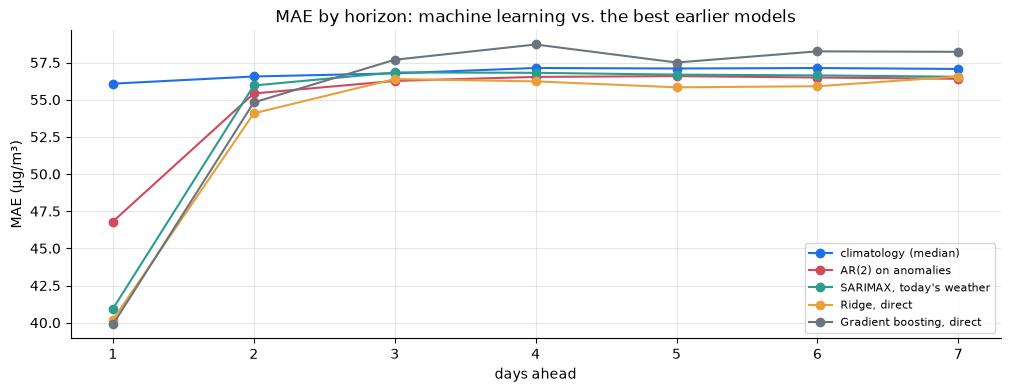

In [5]:
fig, ax = plt.subplots()
for name in leaders:
    ax.plot(board.index, board[name], marker="o", label=name)
ax.set(title="MAE by horizon: machine learning vs. the best earlier models", xlabel="days ahead", ylabel="MAE (µg/m³)")
ax.legend(fontsize=8);

**Ridge regression is among the best honest models on the scoreboard for days 1 and 2**: narrowly ahead of chapter 07's SARIMAX at day 1, and clearly ahead of everything at day 2. From day 3 on it sits with the rest of the pack at the climatology level. It combines what the earlier chapters found separately: today's value (AR memory), today's weather (chapter 07), the season and holidays.

**Gradient boosting** is the best of all at day 1, by a whisker, and second only to ridge at day 2. Then it **falls behind from day 3 on**, below plain climatology at every longer horizon. That isn't a bug. It's a lesson about the data:

- We have about 1,400 training rows per model. At long horizons the signal is weak (chapter 03's one-day half-life), so a flexible learner spends its flexibility **fitting noise**, while ridge's rigidity protects it.
- The strongest relationships here are close to linear on the log scale, such as "today's anomaly carries partly into tomorrow" and "evening wind lowers tomorrow". A linear model captures them with a handful of numbers.

Boosting pays off with **more data** (for example, thousands of related series) and **genuine non-linear interactions**. On one short daily series, a well-chosen linear model is very hard to beat, and Exercise 2 shows that honest tuning narrows the gap without closing it.

---
## 5. What did the models learn?

Ridge's standardised coefficients show how each feature moves the forecast, per standard deviation. We fit on 2010–2013 and compare the model for tomorrow with the one for a week ahead.

In [6]:
def ridge_coefficients(h):
    X = tsutils.ml_features(y, weather, h)
    target = np.log(actual).shift(-h)
    usable = X.notna().all(axis=1) & target.notna() & (X.index <= pd.Timestamp("2013-12-31") - pd.Timedelta(days=h))
    model = ridge().fit(X[usable], target[usable])
    return pd.Series(model.named_steps["ridge"].coef_, index=X.columns)

coefficients = pd.DataFrame({"1 day ahead": ridge_coefficients(1), "7 days ahead": ridge_coefficients(7)})
coefficients.reindex(coefficients["1 day ahead"].abs().sort_values(ascending=False).index).head(12)

,1 day ahead,7 days ahead
nw_evening,-0.400,0.046
humidity_evening,0.262,-0.054
lag_0,0.210,-0.008
humidity,-0.205,0.035
change_1,0.188,-0.001
humidity_change,-0.095,-0.002
mean_3,0.088,-0.002
nw_share,0.071,-0.077
pressure_change,0.051,0.023
sin_1,0.051,-0.036


The two models tell very different stories.

- **One day ahead:** **today's weather** carries the most weight, above all the evening north-westerly wind, exactly chapter 07's finding. Evening humidity is next, then today's level (`lag_0`, `change_1`, `mean_3`). Correlated features share the credit between them. For example, same-day humidity gets a *negative* coefficient only because evening humidity already carries a strong positive one, so read individual coefficients with care.
- **Seven days ahead:** **every coefficient is small**, a fraction of the day-1 values, and no block of features dominates. The model has learned, from data alone, that very little is predictable a week out, so it forecasts close to the average level with small adjustments. The weather terms that remain most likely act as rough indicators of the season. This is chapter 03's one-day half-life, rediscovered by a regression.

---
## 6. Three leakage traps

A generic learner can't tell a legitimate feature from a leaky one, so each trap below produces a model that looks better than it is.

### Trap 1: a feature that peeks at the future

A *centred* 7-day mean (chapter 01) averages three days before and three days **after** each date. Swap it in for the trailing `mean_7`:

In [7]:
def features_with_centred_mean(h):
    X = tsutils.ml_features(y, weather, h)
    X["mean_7"] = np.log(y).rolling(7, center=True).mean()          # uses days t+1 .. t+3!
    return X

leaky_centred = score(direct_forecasts(boosting, features=features_with_centred_mean))
pd.DataFrame({"honest": ml_scores["Gradient boosting, direct"]["MAE"], "centred mean_7 (leaky)": leaky_centred["MAE"]})

,honest,centred mean_7 (leaky)
h,,
1,39.879,31.714
2,54.816,28.410
3,57.687,38.134
4,58.713,56.045
5,57.502,56.799
6,58.252,59.228
7,58.221,57.212


The leaky model looks spectacular for days 1–3, **beating even chapter 07's oracle with perfect weather**, then drops back to normal from day 4, because a centred 7-day window reaches exactly three days ahead. That pattern, remarkable accuracy up to a horizon that matches some window length and then nothing, is a classic signature of leakage. If a result looks too good to be true, compare its horizon profile with the windows in your features.

### Trap 2: shuffled cross-validation

The default habit in machine learning is K-fold cross-validation with **shuffled** rows. For time series, that means training on Thursday and "testing" on the Wednesday before it. How much does it matter here? We compare shuffled 5-fold CV with **time-ordered** splits (`TimeSeriesSplit`, where each fold trains only on the past), for the one-day-ahead models on 2010–2014.

In [8]:
X_dev = tsutils.ml_features(y, weather, 1)
target_dev = np.log(actual).shift(-1)
keep = X_dev.notna().all(axis=1) & target_dev.notna() & (X_dev.index <= pd.Timestamp(tsutils.DEV_END) - pd.Timedelta(days=1))
X_dev, target_dev = X_dev[keep], target_dev[keep]

def cv_mae(make_model, splitter):
    errors = []
    for train_idx, test_idx in splitter.split(X_dev):
        model = make_model().fit(X_dev.iloc[train_idx], target_dev.iloc[train_idx])
        errors.append(np.abs(np.exp(model.predict(X_dev.iloc[test_idx])) - np.exp(target_dev.iloc[test_idx])))
    return np.concatenate(errors).mean()

pd.DataFrame({
    name: {"shuffled 5-fold": cv_mae(make, KFold(5, shuffle=True, random_state=0)),
           "time-ordered 5-fold": cv_mae(make, TimeSeriesSplit(5))}
    for name, make in [("Ridge", ridge), ("Gradient boosting", boosting)]
}).T

,shuffled 5-fold,time-ordered 5-fold
Ridge,40.998,40.853
Gradient boosting,40.896,42.438


Here the damage is **modest**. Shuffling flatters gradient boosting by a few percent and barely affects ridge. (The comparison isn't perfectly like-for-like either: the early time-ordered folds train on less data, which works against them.) Two reasons it's this small here: our features are all trailing, so no single row contains its neighbours' targets, and daily PM2.5 forgets within a day or two. The optimism grows with model flexibility and with how strongly neighbouring rows share information. With hourly data, overlapping windows or deep trees it can be severe, and you can't know how big it will be **without measuring it**. Time-ordered evaluation costs nothing and removes the question.

### Trap 3: training rows whose targets lie in the future

Section 3's rule was that the target date, not the row date, must fall before the refit date. What if we only checked the row date?

In [9]:
leaky_cutoff = score(direct_forecasts(boosting, cutoff="row"))
pd.DataFrame({"honest cut-off (target date)": ml_scores["Gradient boosting, direct"]["MAE"],
              "leaky cut-off (row date)": leaky_cutoff["MAE"]})

,honest cut-off (target date),leaky cut-off (row date)
h,,
1,39.879,39.595
2,54.816,54.264
3,57.687,57.120
4,58.713,57.429
5,57.502,56.925
6,58.252,59.040
7,58.221,57.554


The leaky cut-off looks slightly better at most horizons, by about half a µg/m³ on average. The effect is noisy, and one horizon even gets worse, because each monthly model trains on only a few extra leaked rows. An $h$-day model trains on targets up to $h$ days past the refit date, which overlaps the very days it's then asked to forecast. The gain is small, but it's pure illusion, and this off-by-$h$ bug is exactly the kind that slips through code review, because its symptom is a result that looks only a *little* better. The fix costs nothing: always filter training rows by **when the target became known**.

> **Checklist for any ML forecast:** (1) every feature known at the origin? (2) trailing windows only? (3) evaluation ordered in time? (4) training cut-off on the *target* date? (5) is the horizon profile of the accuracy plausible?

---
## Exercises

### Exercise 1: Direct vs. recursive
To isolate the *strategy*, use only lag features: `lag_0`, `lag_1`, `lag_2`, `lag_3`, `lag_6`, `mean_3` and `mean_7`. Build a **recursive** ridge forecaster: fit one model for $h = 1$ (refitted monthly, same honest cut-off), then at each origin predict tomorrow, append that prediction to the series, recompute the seven features, and repeat for 7 steps. Compare it with **direct** ridge models on the same features.

<details><summary>Solution</summary>

```python
lag_cols = ["lag_0", "lag_1", "lag_2", "lag_3", "lag_6", "mean_3", "mean_7"]

def lag_features_from(values):
    """The seven lag features for the last position of an array of log values."""
    return np.array([values[-1], values[-2], values[-3], values[-4], values[-7],
                     values[-3:].mean(), values[-7:].mean()])

X_lags = tsutils.ml_features(y, weather, 1)[lag_cols]
target_1 = np.log(actual).shift(-1)
complete = X_lags.notna().all(axis=1) & target_1.notna()
log_y = np.log(y)

recursive = {}
for _, month_origins in pd.Series(origins, index=origins).groupby([origins.year, origins.month]):
    refit = month_origins.iloc[0]
    usable = complete & (X_lags.index <= refit - pd.Timedelta(days=1))
    model = ridge().fit(X_lags[usable], target_1[usable])
    for origin_ in month_origins:
        values = list(log_y[:origin_].to_numpy()[-30:])
        for h in range(1, H + 1):
            step = model.predict(pd.DataFrame([lag_features_from(np.array(values))], columns=lag_cols))[0]
            values.append(step)
            recursive[(origin_, h)] = np.exp(step)

direct = direct_forecasts(ridge, features=lambda h: tsutils.ml_features(y, weather, h)[lag_cols])
pd.DataFrame({"recursive": score(recursive)["MAE"], "direct": score(direct)["MAE"]})
```
With lag features only, the two strategies end up close: both are essentially AR models, and for linear models the recursive and direct forecasts differ mainly in how they're fitted. The practical differences show up elsewhere. The recursive strategy has no honest way to use weather features beyond day 1, since future weather would have to be invented (chapter 07's approach B problem). Its errors also compound through the recursion, which matters more for non-linear models. The direct strategy sidesteps both, at the cost of training $H$ models.
</details>

### Exercise 2: Tune gradient boosting honestly
Try `max_iter` values of 50, 100 and 200 with `max_leaf_nodes=7` (simpler trees than before). Choose the setting on a **2013** backtest for horizons 1 and 5, then report its **2014** MAE. Does honest tuning close the gap to ridge?

<details><summary>Solution</summary>

```python
tuning_origins = pd.date_range("2012-12-31", "2013-12-24", freq="D")

def mae_for(forecasts, h, origins_):
    """MAE of the h-step forecasts, skipping days with no scorable actual."""
    errors = [abs(forecasts[(o, h)] - actual.get(o + pd.Timedelta(days=h), np.nan)) for o in origins_]
    return np.nanmean(errors)

rows = {}
for n_trees in [50, 100, 200]:
    make = lambda n=n_trees: HistGradientBoostingRegressor(max_iter=n, learning_rate=0.05, max_leaf_nodes=7,
                                                            min_samples_leaf=20, random_state=0)
    for period, origins_ in [("2013", tuning_origins), ("2014", origins)]:
        fc = direct_forecasts(make, horizons=[1, 5], origins_=origins_)
        for h in [1, 5]:
            rows[(n_trees, f"{period}, h={h}")] = mae_for(fc, h, origins_)

tuning = pd.Series(rows).unstack()
tuning.index.name = "max_iter"
tuning
```
Pick the setting with the lowest 2013 error at each horizon and read its 2014 value. Compare with ridge (`ml_scores["Ridge, direct"]`). Simpler, shorter-trained boosting usually does better at day 5, where there's little signal to find, but it still doesn't clearly beat ridge. More flexibility buys nothing when the signal is weak and nearly linear. Tuning the model's **capacity** to the data matters more than the choice of algorithm.
</details>

### Exercise 3: Prediction intervals with quantile regression
Gradient boosting can predict **quantiles** directly with `loss="quantile"`. Train one-day-ahead models for the 10% and 90% quantiles (`quantile=0.1` and `0.9`) with the monthly schedule, and measure how often 2014's actual values fall between them. Compare with chapter 06's AR(2) intervals (78–80%).

<details><summary>Solution</summary>

```python
def quantile_model(q):
    return lambda: HistGradientBoostingRegressor(loss="quantile", quantile=q, max_iter=200, learning_rate=0.05,
                                                 max_leaf_nodes=15, min_samples_leaf=20, random_state=0)

lower = direct_forecasts(quantile_model(0.1), horizons=[1])
upper = direct_forecasts(quantile_model(0.9), horizons=[1])
rows = [(lower[(o, 1)], upper[(o, 1)], actual.get(o + pd.Timedelta(days=1), np.nan)) for o in origins]
band = pd.DataFrame(rows, columns=["lower", "upper", "actual"]).dropna()
inside = (band["actual"] >= band["lower"]) & (band["actual"] <= band["upper"])
print(f"coverage of the 80% interval, 1 day ahead: {inside.mean():.0%}")
print(f"median interval width: {(band['upper'] - band['lower']).median():.0f} µg/m³")
```
Coverage comes out at only about **two in three**, well short of the promised 80%. The intervals are much narrower than chapter 04's climatology intervals, because the model knows today's conditions, but they're *too* narrow. Two reasons. Each monthly model learns its extreme quantiles from only about 1,400 rows, and boosted trees tend to pull extreme quantiles towards the middle on small data. And 2014 had larger swings than the training years, which chapter 04 already found with naive's intervals.

Learning quantiles directly doesn't guarantee calibrated intervals, so **check coverage out of sample**. The standard repair is a **calibration step**, often called *conformal prediction*: measure how far actuals fall outside the raw intervals on a held-out year (2013), and widen the intervals by that amount. Quantile models trained separately can also occasionally cross (lower above upper), so check for that in production code.
</details>

### Exercise 4: Which feature blocks matter?
Run the ridge model four more times, each time dropping one block: the lags and trailing statistics, the weather, the calendar (Fourier terms, weekday, festival flags), and the festival flags alone. Compare MAE at 1, 2 and 7 days ahead with the full model.

<details><summary>Solution</summary>

```python
columns = tsutils.ml_features(y, weather, 1).columns
blocks = {
    "lags & trailing stats": [c for c in columns if c.startswith(("lag_", "mean_", "std_", "change_"))],
    "weather": tsutils.KNOWN_TODAY_WEATHER,
    "calendar": [c for c in columns if c.startswith(("sin_", "cos_", "target_"))],
    "festival flags only": ["target_is_festival", "target_is_festival_eve"],
}
ablation = {"full model": ml_scores["Ridge, direct"]["MAE"]}
for block, cols in blocks.items():
    ablation[f"without {block}"] = score(direct_forecasts(ridge, drop=cols))["MAE"]
pd.DataFrame(ablation).loc[[1, 2, 7]].T
```
Dropping the **weather** hurts most at day 1, and dropping the **lags** nearly as much. Neither matters much by day 7, which matches chapters 03 and 07.

The surprise is the **calendar**. Dropping it makes the model slightly *better* at every horizon. The seasonal level is already carried by the trailing 30-day mean, so the Fourier terms add parameters without adding usable information. And a weekday coded as the integer 0–6 is a poor input for a linear model anyway. The festival flags barely change the averages: they matter on about three days a year, so an average over 359 origins hides them. Check such features on the days they're meant for.

Should you now remove the calendar block? Not on this evidence. **We found it by looking at 2014, the year we report on**, which is exactly the tuning-on-the-test-set trap from chapter 04. The honest procedure is to run the same ablation on the 2013 backtest, decide there, and only then check 2014.
</details>

---
## Key takeaways

- Forecasting becomes supervised learning with **one row per origin**, features **known at that origin**, and a target $h$ days later.
- The **direct** strategy, one model per horizon, fits each horizon properly and uses today's weather without inventing future weather.
- **Ridge regression** on lag, weather and calendar features is the **best honest model so far at day 2** and a near-tie for best at day 1. **Gradient boosting** edges it at day 1 but **overfits** from day 3, where the signal is weak and nearly linear.
- The models rediscovered the course's story: **weather and memory for tomorrow; for next week, little beyond the average level**.
- Leakage traps, in order of how loudly they announce themselves: **centred features** (spectacular and fake), **shuffled CV** (modest here, but unpredictable), **training cut-off by row date** (small, noisy and silent).
- New scoreboard entries: `Ridge, direct` and `Gradient boosting, direct`.

**Next:** *10 · Deep Learning*. Recurrent networks and LSTMs learn their own features from raw sequences. We'll give them a fair, carefully validated chance against the ridge model.